In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [41]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
roc_curve,
auc
)

In [42]:
data = load_breast_cancer()

In [43]:
x = data.data
y = data.target

print("Dataset Shape:",x.shape)
print("Classes: ",np.unique(y))

Dataset Shape: (569, 30)
Classes:  [0 1]


In [44]:
X_train,X_test, y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)
# stratify : y , both the training and testing sets will become have approx the same percentages.

In [87]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mle_model = LogisticRegression(
    penalty = None,
    max_iter = 5000, 
    random_state=42
)

mle_model.fit(X_train_scaled,y_train)

y_pred_mle = mle_model.predict(X_test_scaled)

In [88]:
map_l1 = LogisticRegression(
penalty='l1', #  # L1 regularization (Lasso)
    C=1.0,
    solver ='liblinear', # solver is the optimization algorithm that find best coefficients
    max_iter=5000,
    random_state = 42,
)

map_l1.fit(X_train_scaled,y_train)
y_pred_l1 = map_l1.predict(X_test_scaled)

In [89]:
map_l2 = LogisticRegression(
penalty='l2', # L2 Regularization (Ridge Regulariation)
    C=1.0,
    solver ='lbfgs', # solver is the optimization algorithm that find best coefficients
    max_iter=5000,
    random_state = 42,
)

map_l2.fit(X_train_scaled,y_train)
y_pred_l2 = map_l2.predict(X_test_scaled)

In [90]:
def evaluate(model_name,y_true,y_pred):
    print("\n","="*40)
    print(model_name)
    print("="*40)

    print("Accuracy: ",accuracy_score(y_true,y_pred))
    print("Precision: ",precision_score(y_true,y_pred))
    print("Recall: ",recall_score(y_true,y_pred))
    print("F1: ",f1_score(y_true,y_pred))
          
    print("\n Confusion Matrix ")
    print(confusion_matrix(y_true,y_pred))
    
evaluate("MLE",y_test,y_pred_mle)
evaluate("MAP(L2)",y_test,y_pred_l2)
evaluate("MAP(L1)",y_test,y_pred_l1)


MLE
Accuracy:  0.9210526315789473
Precision:  0.9701492537313433
Recall:  0.9027777777777778
F1:  0.935251798561151

 Confusion Matrix 
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy:  0.9824561403508771
Precision:  0.9861111111111112
Recall:  0.9861111111111112
F1:  0.9861111111111112

 Confusion Matrix 
[[41  1]
 [ 1 71]]

MAP(L1)
Accuracy:  0.9912280701754386
Precision:  0.9863013698630136
Recall:  1.0
F1:  0.993103448275862

 Confusion Matrix 
[[41  1]
 [ 0 72]]


In [91]:
print("number of zero Coefficients")
print("MLE:",np.sum(mle_model.coef_[0]==0))
print("MAP L2:",np.sum(map_l2.coef_[0]==0))
print("MAP L1:",np.sum(map_l1.coef_[0]==0))

number of zero Coefficients
MLE: 0
MAP L2: 0
MAP L1: 14


In [92]:
results = pd.DataFrame(
    columns=["model","Accuracy","Precision","Recall","F1 Score"]
)
models = [
    ("MLE   ",mle_model,y_pred_mle),
    ("MAP L2",map_l2,y_pred_l2),
    ("MAP L1",map_l1,y_pred_l1)
]

for name, model ,pred in models:
    results.loc[len(results)] = [
        name, 
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]

print(results)
        

    model  Accuracy  Precision    Recall  F1 Score
0  MLE     0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


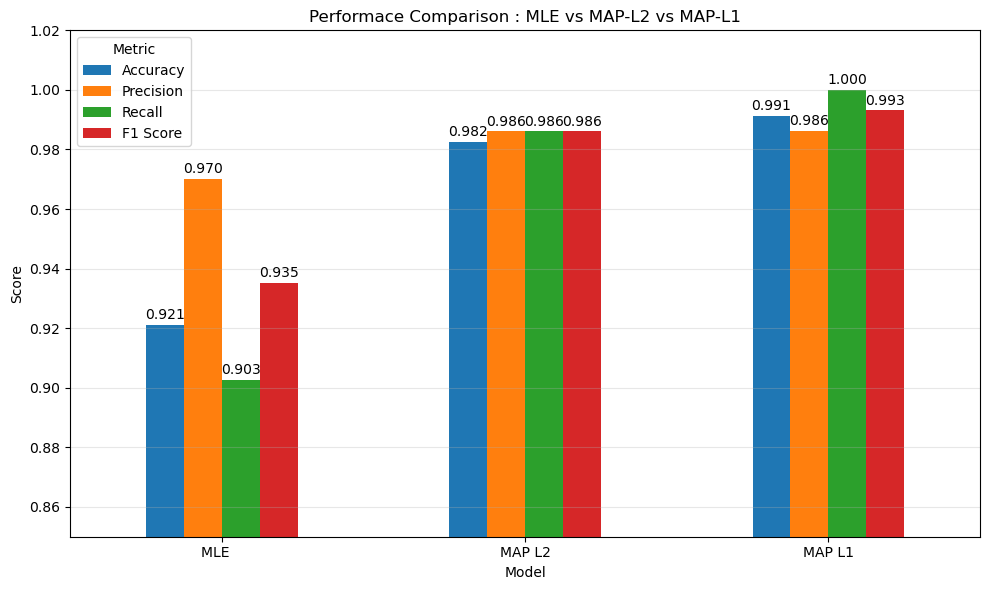

In [98]:
ax=results.set_index("model").plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Performace Comparison : MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()

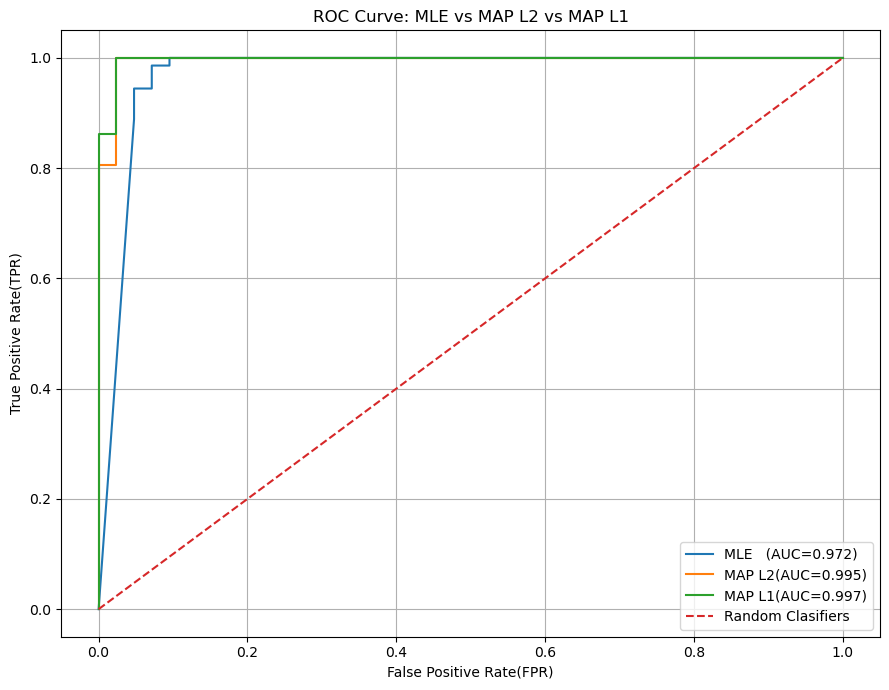

In [113]:
plt.figure(figsize=(9,7))
for name, model, pred in models:
    y_prob =  model.predict_proba(X_test_scaled)[:,1] # Give Probability of each class

    fpr,tpr,thresholds = roc_curve(y_test,y_prob) # calculate ROC values

    roc_auc = auc(fpr, tpr) # calculate AUC values

    plt.plot(
        fpr,
        tpr,
        label=f"{name}(AUC={roc_auc:.3f})"
    )

#plt.xlim(0,0.15)
#plt.ylim(0.75,1.01)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label = "Random Clasifiers"
)

plt.xlabel("False Positive Rate(FPR)")
plt.ylabel("True Positive Rate(TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

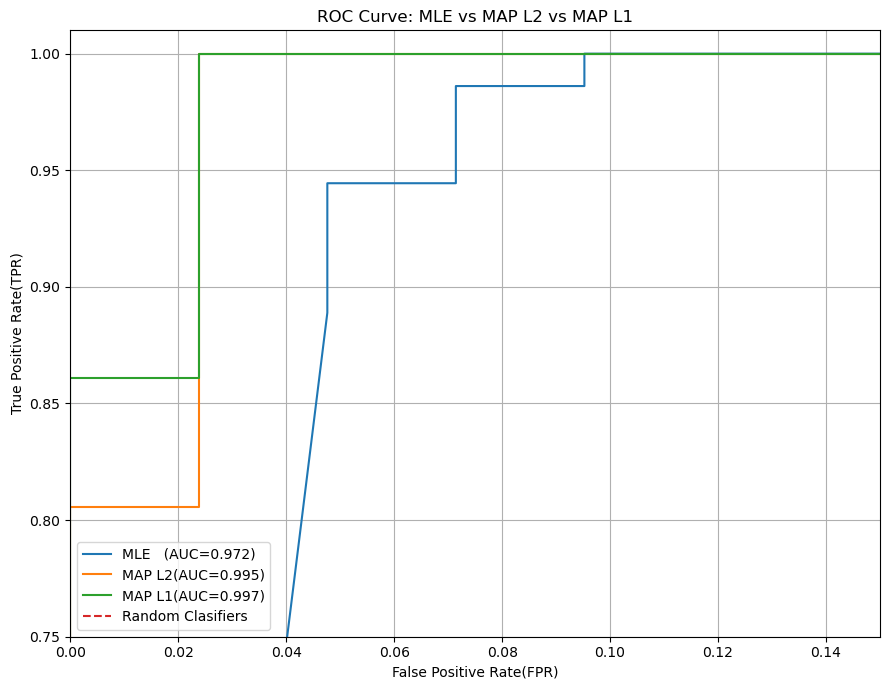

In [114]:
# Zoomed Version

plt.figure(figsize=(9,7))
for name, model, pred in models:
    y_prob =  model.predict_proba(X_test_scaled)[:,1] # Give Probability of each class

    fpr,tpr,thresholds = roc_curve(y_test,y_prob) # calculate ROC values

    roc_auc = auc(fpr, tpr) # calculate AUC values

    plt.plot(
        fpr,
        tpr,
        label=f"{name}(AUC={roc_auc:.3f})"
    )

plt.xlim(0,0.15)
plt.ylim(0.75,1.01)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label = "Random Clasifiers"
)

plt.xlabel("False Positive Rate(FPR)")
plt.ylabel("True Positive Rate(TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()